# Predicting Subscription Fatigue and OTT Platform Switching Behavior Among Digital Streaming Users

**Student:** Harshini Vennela  
**Register Number:** CB.SC.U4CSE23455  
**Section:** E  
**Domain:** Entertainment / OTT Streaming Services

## 1. Business Problem

OTT platforms can lose subscribers when users experience subscription fatigue and consider switching to another platform.

This study analyzes usage, expenditure, content satisfaction, pricing satisfaction, streaming experience, and competitor awareness to identify users likely to switch their primary OTT platform.

Subscription fatigue is analyzed across three dimensions:
- Cost-driven fatigue
- Content-driven fatigue
- Experience-driven fatigue


## 2. Business Objectives

1. Identify the major factors contributing to subscription fatigue.
2. Diagnose whether fatigue is primarily cost-driven, content-driven, or experience-driven.
3. Analyze the influence of pricing, content quality, viewing behaviour, and customer satisfaction on platform switching.
4. Develop a classification model to identify users likely to switch their primary OTT platform.
5. Provide fatigue-type-specific, data-driven recommendations for customer retention.


## 3. Dataset and Data Collection

**Collection method.** The primary data was collected with a Google Forms questionnaire shared with OTT subscribers. No names, e-mail addresses or phone numbers were kept; every row is identified only by `Record_ID`.

**What the analytical dataset contains.** The questionnaire produced **13 real responses**. That is too few to train and test a classifier, so the analytical file `data/final_ott_dataset_10000.csv` holds **10,000 records: 13 real + 9,987 synthetic**. The synthetic rows were generated from the answer patterns and relationships seen in the real responses. The `Data_Source` column marks every row as `Real` or `Synthetic` (the counts are printed in Section 5).

**How to read the results.** About 99.9% of the rows are synthetic, so every percentage, chart and model score below describes this analytical dataset. It is not evidence about the wider population of OTT users. The notebook is a worked demonstration of the analytics pipeline; the findings are hypotheses to be re-tested on genuinely collected responses.

> Note for the repository: keep the script or notes used to generate the synthetic rows in `data/`, and add the raw 13-row survey export, so that the data-collection method is fully documented.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")


Libraries imported successfully.


## 4. Load Dataset

In [2]:
from pathlib import Path

# analysis.ipynb sits in the repository root and the CSV lives in data/
DATA_PATH = next(p for p in [Path("data/final_ott_dataset_10000.csv"),
                             Path("../data/final_ott_dataset_10000.csv")] if p.exists())
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (10000, 32)


,Record_ID,Age_Numeric,Gender,Occupation,Income_Numeric,Primary_OTT_Platform,Subscriptions_Numeric,Tenure_Months,Monthly_Spend_Numeric,Share_Account,Hours_Watched_Numeric,Preferred_Genre,Primary_Device,Usual_Viewing_Time,Pricing_Satisfaction,Content_Satisfaction,Content_Variety,Recommendation_Quality,Advertisement_Tolerance,Streaming_Experience,Switched_Before,Competitor_Awareness,Switch_Intent,Main_Reason_For_Switching,What_Would_Encourage_Stay,Suggestions_To_Improve,Data_Source,Cost_Fatigue_Score,Content_Fatigue_Score,Experience_Fatigue_Score,Overall_Fatigue_Score,Dominant_Fatigue_Type
0,1,21.0,Male,Student,12500,Netflix,5.0,30.0,750,No,7.5,Comedy,Smart TV,Night,3,5,4,5,3,3,Yes,No,Yes,Expensive subscription,Lower price,Lower subscription prices,Synthetic,54.86,29.0,46.0,43.29,Cost
1,2,21.0,Male,Student,0,Amazon Prime Video,5.0,9.0,100,Yes,7.5,Horror,Laptop/Desktop,Night,4,5,2,4,3,3,No,No,Yes,Buffering and playback issues,Better recommendations,Reduce buffering,Synthetic,29.71,47.0,53.0,43.24,Experience
2,3,39.5,Male,Student,0,Netflix,2.0,30.0,350,No,7.5,Action,Mobile,Evening,5,5,4,5,1,4,Yes,No,No,No plans to switch,"Better streaming quality, Fewer ads",Offer better family plans,Synthetic,20.00,29.0,45.0,31.33,Experience
3,4,21.0,Female,Student,0,Netflix,5.0,4.5,100,No,7.5,Comedy,Laptop/Desktop,Night,4,5,5,5,1,4,Yes,No,No,No plans to switch,Better streaming quality,Add more exclusive content,Synthetic,29.71,20.0,45.0,31.57,Experience
4,5,21.0,Female,Working Professional,0,Netflix,2.0,1.5,350,No,2.5,Action,Laptop/Desktop,Evening,4,5,5,5,3,3,No,Yes,No,No plans to switch,Better streaming quality,Improve recommendations,Synthetic,34.00,20.0,46.0,33.33,Experience


## 5. Dataset Information

In [3]:
print("Number of records:", len(df))
print("Number of columns:", len(df.columns))

print("\nData source:")
print(df["Data_Source"].value_counts())

print("\nData types:")
print(df.dtypes)


Number of records: 10000
Number of columns: 32

Data source:
Data_Source
Synthetic    9987
Real           13
Name: count, dtype: int64

Data types:
Record_ID                      int64
Age_Numeric                  float64
Gender                           str
Occupation                       str
Income_Numeric                 int64
Primary_OTT_Platform             str
Subscriptions_Numeric        float64
Tenure_Months                float64
Monthly_Spend_Numeric          int64
Share_Account                    str
Hours_Watched_Numeric        float64
Preferred_Genre                  str
Primary_Device                   str
Usual_Viewing_Time               str
Pricing_Satisfaction           int64
Content_Satisfaction           int64
Content_Variety                int64
Recommendation_Quality         int64
Advertisement_Tolerance        int64
Streaming_Experience           int64
Switched_Before                  str
Competitor_Awareness             str
Switch_Intent                    str
M

## 6. Data Quality Check

In [4]:
print("Duplicate rows:", df.duplicated().sum())
print("Duplicate Record IDs:", df["Record_ID"].duplicated().sum())

print("\nMissing values:")
missing = df.isnull().sum()
print(missing[missing > 0])


Duplicate rows: 0
Duplicate Record IDs: 0

Missing values:
Switched_Before              1
Competitor_Awareness         1
Switch_Intent                1
Main_Reason_For_Switching    1
What_Would_Encourage_Stay    1
Suggestions_To_Improve       7
dtype: int64


### 6.1 Real vs synthetic rows

Because almost all rows are synthetic, it is worth checking how the 13 real responses compare with the synthetic ones on the main rating variables. With only 13 real rows this is a rough sanity check, not a statistical test.

In [5]:
rating_cols = ["Pricing_Satisfaction", "Content_Satisfaction", "Content_Variety",
               "Recommendation_Quality", "Advertisement_Tolerance", "Streaming_Experience"]

print(df["Data_Source"].value_counts(), "\n")
print("Mean rating by data source:")
display(df.groupby("Data_Source")[rating_cols].mean().round(2))

print("Switch intention by data source (counts):")
display(pd.crosstab(df["Data_Source"], df["Switch_Intent"]))

Data_Source
Synthetic    9987
Real           13
Name: count, dtype: int64 

Mean rating by data source:


,Pricing_Satisfaction,Content_Satisfaction,Content_Variety,Recommendation_Quality,Advertisement_Tolerance,Streaming_Experience
Data_Source,,,,,,
Real,3.38,4.23,4.00,4.23,3.15,3.85
Synthetic,3.37,4.21,3.96,4.21,3.16,3.84


Switch intention by data source (counts):


Switch_Intent,No,Yes
Data_Source,,
Real,11,1
Synthetic,7000,2987


## 7. Descriptive Statistics

In [6]:
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
Record_ID,10000.0,5000.500000,2886.895680,1.00,2500.75,5000.50,7500.25,10000.00
Age_Numeric,10000.0,25.969000,9.415302,21.00,21.00,21.00,21.00,49.50
Income_Numeric,10000.0,18881.250000,36163.964200,0.00,0.00,0.00,12500.00,125000.00
Subscriptions_Numeric,10000.0,2.765400,1.358288,1.00,2.00,2.00,3.00,5.00
Tenure_Months,10000.0,11.392800,10.619973,1.50,4.50,9.00,9.00,30.00
Monthly_Spend_Numeric,10000.0,544.770000,417.028222,100.00,350.00,350.00,750.00,1750.00
Hours_Watched_Numeric,10000.0,7.596000,3.799635,2.50,7.50,7.50,7.50,15.00
Pricing_Satisfaction,10000.0,3.370500,1.059878,1.00,3.00,4.00,4.00,5.00
Content_Satisfaction,10000.0,4.211400,0.748843,2.00,4.00,4.00,5.00,5.00
Content_Variety,10000.0,3.962000,0.835719,2.00,3.00,4.00,5.00,5.00


## 8. Categorical Variable Analysis

In [7]:
categorical_cols = [
    "Gender",
    "Occupation",
    "Primary_OTT_Platform",
    "Share_Account",
    "Preferred_Genre",
    "Primary_Device",
    "Usual_Viewing_Time",
    "Switched_Before",
    "Competitor_Awareness",
    "Switch_Intent",
    "Dominant_Fatigue_Type"
]

for col in categorical_cols:
    print("\n===", col, "===")
    print(df[col].value_counts())



=== Gender ===
Gender
Male      6134
Female    3866
Name: count, dtype: int64

=== Occupation ===
Occupation
Student                 6942
Working Professional    1534
Homemaker               1524
Name: count, dtype: int64

=== Primary_OTT_Platform ===
Primary_OTT_Platform
Netflix               6925
Amazon Prime Video    2340
Disney+ Hotstar        735
Name: count, dtype: int64

=== Share_Account ===
Share_Account
Yes    5439
No     4561
Name: count, dtype: int64

=== Preferred_Genre ===
Preferred_Genre
Comedy      2326
Romance     1627
Horror      1540
Thriller    1523
Action      1499
Anime        753
Drama        732
Name: count, dtype: int64

=== Primary_Device ===
Primary_Device
Laptop/Desktop    3915
Mobile            3838
Smart TV          2247
Name: count, dtype: int64

=== Usual_Viewing_Time ===
Usual_Viewing_Time
Night      6169
Evening    3831
Name: count, dtype: int64

=== Switched_Before ===
Switched_Before
No     5011
Yes    4988
Name: count, dtype: int64

=== Competitor_

## 9. Exploratory Data Analysis

### 9.1 Primary OTT Platform Distribution

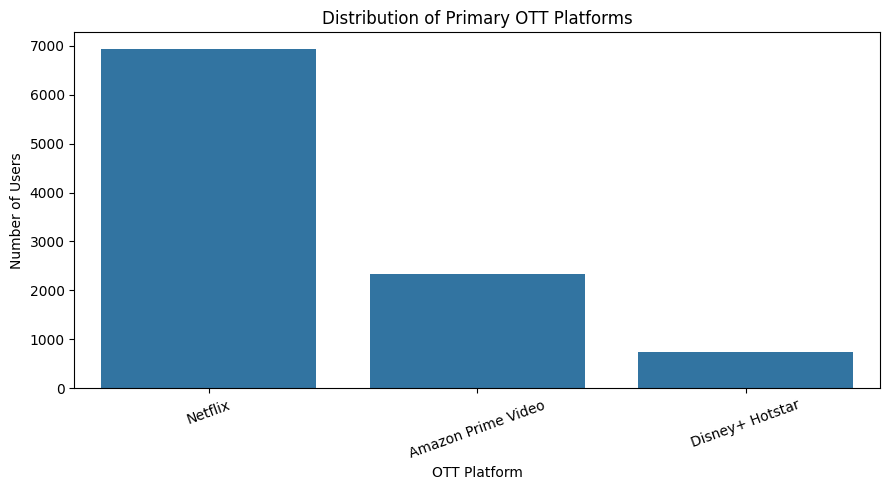

In [8]:
plt.figure(figsize=(9, 5))
sns.countplot(data=df, x="Primary_OTT_Platform")
plt.title("Distribution of Primary OTT Platforms")
plt.xlabel("OTT Platform")
plt.ylabel("Number of Users")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


### 9.2 Occupation Distribution

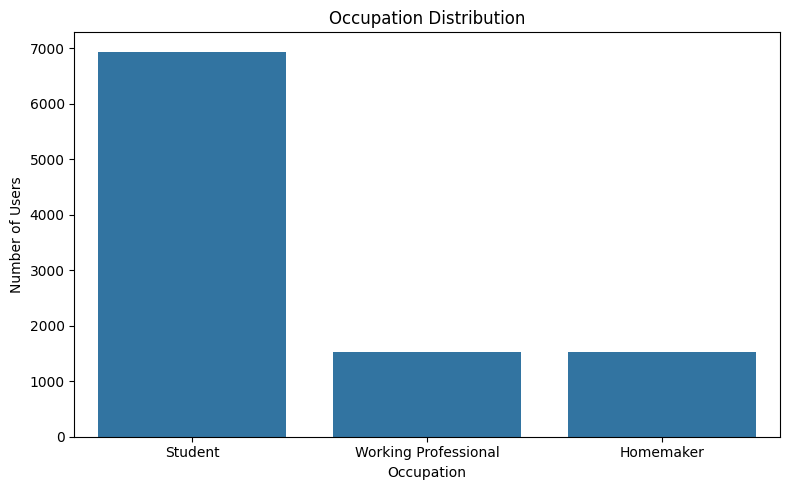

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Occupation")
plt.title("Occupation Distribution")
plt.xlabel("Occupation")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


### 9.3 OTT Subscription Count

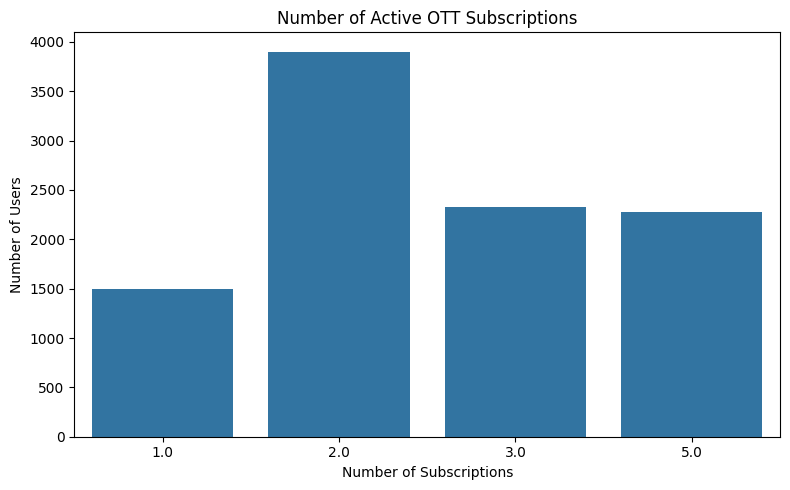

In [10]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Subscriptions_Numeric")
plt.title("Number of Active OTT Subscriptions")
plt.xlabel("Number of Subscriptions")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


### 9.4 Switching Intention

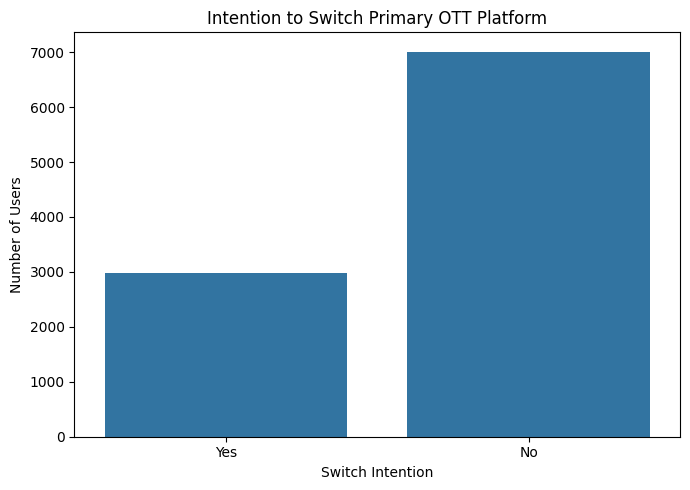

In [11]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Switch_Intent")
plt.title("Intention to Switch Primary OTT Platform")
plt.xlabel("Switch Intention")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


### 9.5 Pricing Satisfaction vs Switching

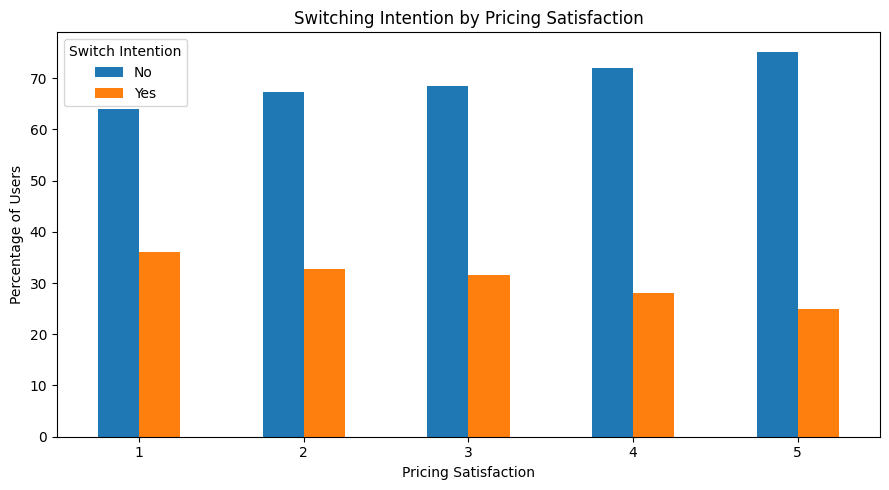

In [12]:
switch_pricing = pd.crosstab(
    df["Pricing_Satisfaction"],
    df["Switch_Intent"],
    normalize="index"
) * 100

switch_pricing.plot(kind="bar", figsize=(9, 5))
plt.title("Switching Intention by Pricing Satisfaction")
plt.xlabel("Pricing Satisfaction")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=0)
plt.legend(title="Switch Intention")
plt.tight_layout()
plt.show()


### 9.6 Content Satisfaction vs Switching

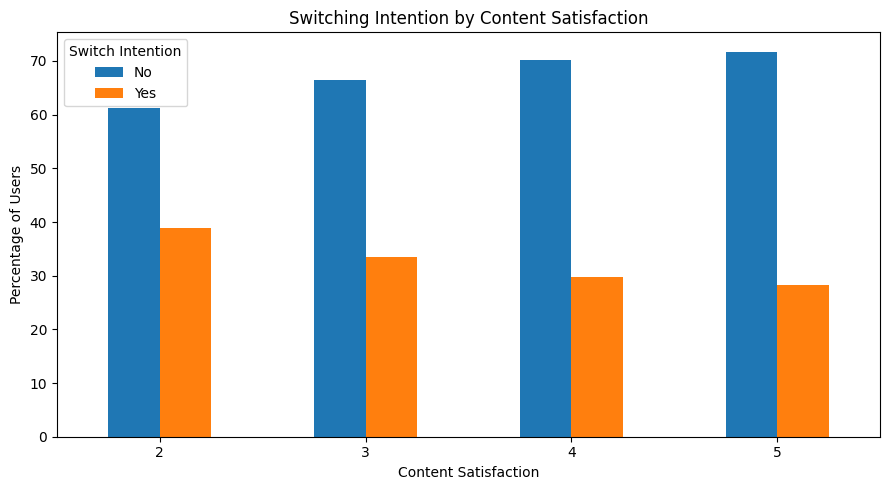

In [13]:
switch_content = pd.crosstab(
    df["Content_Satisfaction"],
    df["Switch_Intent"],
    normalize="index"
) * 100

switch_content.plot(kind="bar", figsize=(9, 5))
plt.title("Switching Intention by Content Satisfaction")
plt.xlabel("Content Satisfaction")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=0)
plt.legend(title="Switch Intention")
plt.tight_layout()
plt.show()


### 9.7 Streaming Experience vs Switching

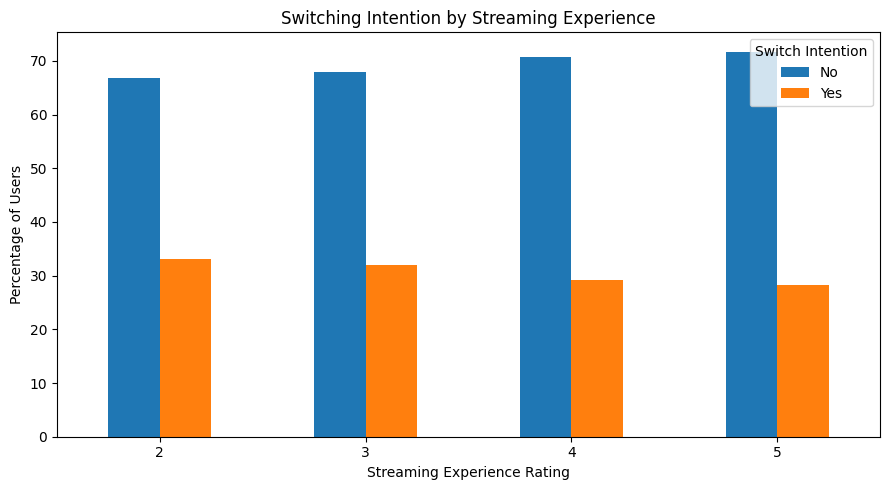

In [14]:
switch_experience = pd.crosstab(
    df["Streaming_Experience"],
    df["Switch_Intent"],
    normalize="index"
) * 100

switch_experience.plot(kind="bar", figsize=(9, 5))
plt.title("Switching Intention by Streaming Experience")
plt.xlabel("Streaming Experience Rating")
plt.ylabel("Percentage of Users")
plt.xticks(rotation=0)
plt.legend(title="Switch Intention")
plt.tight_layout()
plt.show()


### 9.8 Dominant Fatigue Type

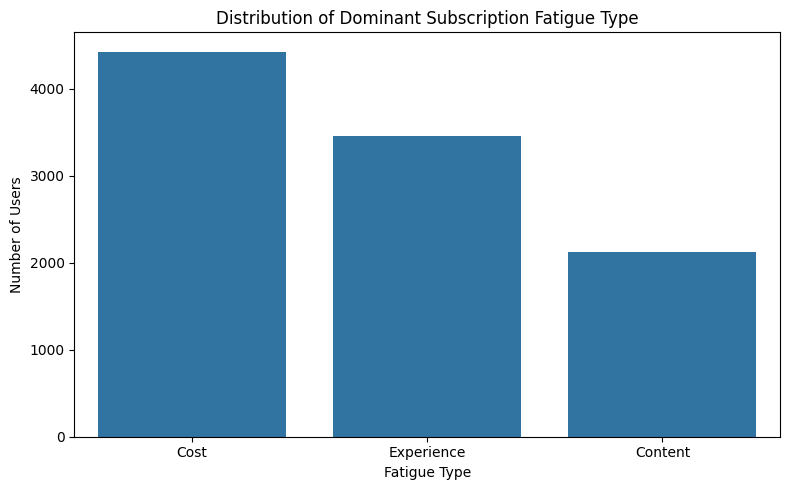

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Dominant_Fatigue_Type")
plt.title("Distribution of Dominant Subscription Fatigue Type")
plt.xlabel("Fatigue Type")
plt.ylabel("Number of Users")
plt.tight_layout()
plt.show()


### 9.9 Correlation Heatmap

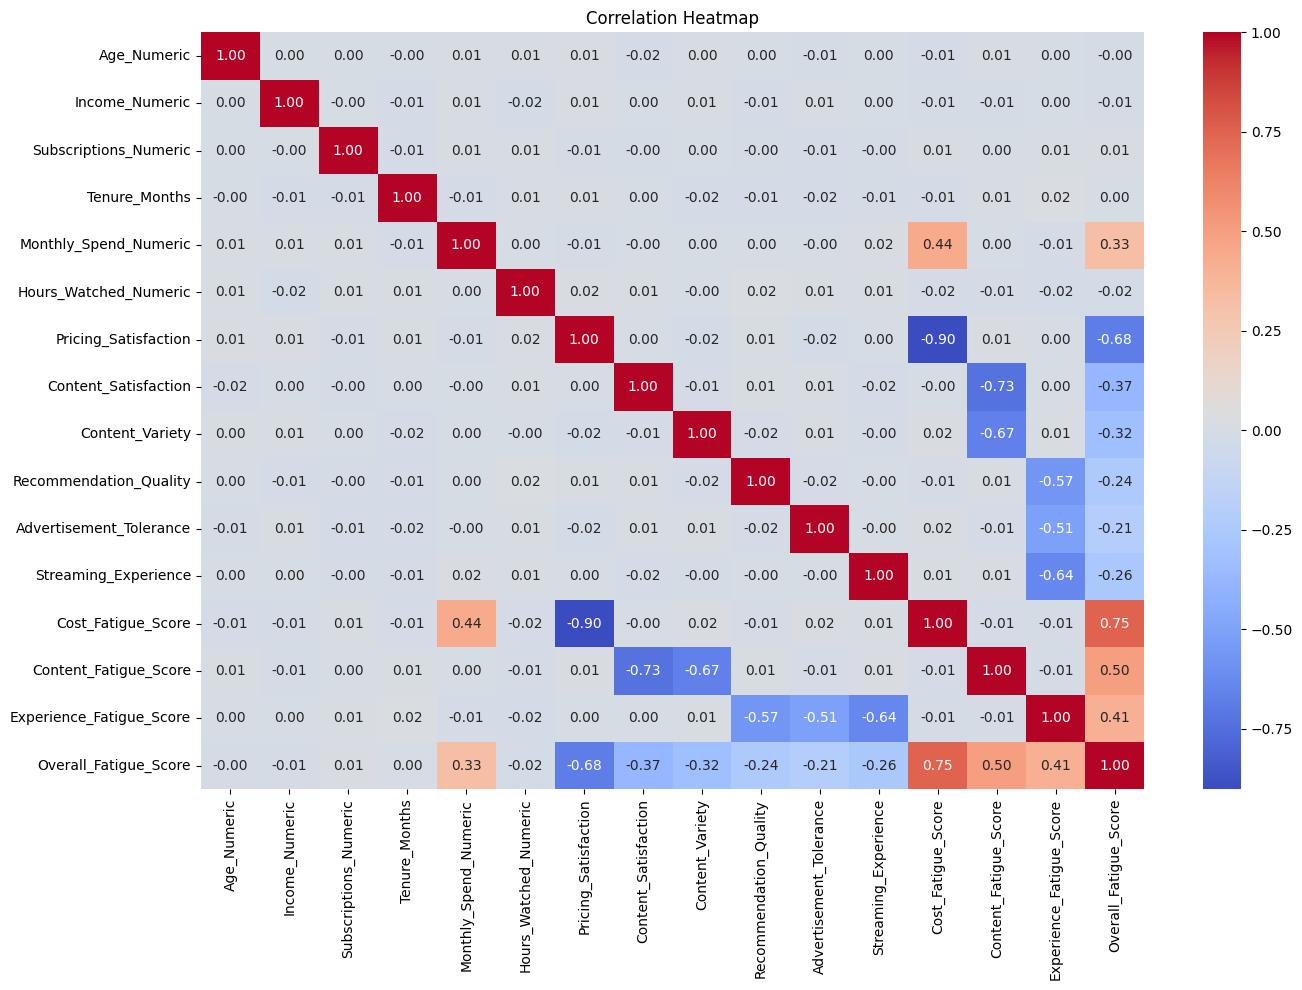

In [16]:
correlation_cols = [
    "Age_Numeric",
    "Income_Numeric",
    "Subscriptions_Numeric",
    "Tenure_Months",
    "Monthly_Spend_Numeric",
    "Hours_Watched_Numeric",
    "Pricing_Satisfaction",
    "Content_Satisfaction",
    "Content_Variety",
    "Recommendation_Quality",
    "Advertisement_Tolerance",
    "Streaming_Experience",
    "Cost_Fatigue_Score",
    "Content_Fatigue_Score",
    "Experience_Fatigue_Score",
    "Overall_Fatigue_Score"
]

plt.figure(figsize=(14, 10))
sns.heatmap(
    df[correlation_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**Reading the heatmap.**
- The fatigue scores are built from the satisfaction items, so they correlate strongly with them (for example, cost fatigue vs pricing satisfaction is about -0.90). This is by construction, and it means the fatigue scores and the raw ratings carry overlapping information.
- The six satisfaction ratings are almost uncorrelated with each other (values close to 0.00). In genuine survey data, satisfaction items normally move together, so this pattern is a sign that the synthetic rows were generated column by column. It is a limitation of the dataset and is noted in the report.
- Age, income, tenure and viewing hours show essentially no relationship with anything else.

## 10. Fatigue Analysis

In [17]:
fatigue_summary = df[
    [
        "Cost_Fatigue_Score",
        "Content_Fatigue_Score",
        "Experience_Fatigue_Score",
        "Overall_Fatigue_Score"
    ]
].describe().T

fatigue_summary


,count,mean,std,min,25%,50%,75%,max
Cost_Fatigue_Score,10000.0,46.152144,16.511915,15.71,34.00,43.71,54.86,100.00
Content_Fatigue_Score,10000.0,38.016600,11.074728,20.00,29.00,38.00,49.00,80.00
Experience_Fatigue_Score,10000.0,43.318700,9.110534,20.00,37.00,44.00,49.00,77.00
Overall_Fatigue_Score,10000.0,42.495764,7.230154,19.90,37.33,42.00,47.00,72.33


### Average Fatigue Score by Switching Intention

In [18]:
fatigue_by_switch = df.groupby(
    "Switch_Intent"
)[
    [
        "Cost_Fatigue_Score",
        "Content_Fatigue_Score",
        "Experience_Fatigue_Score",
        "Overall_Fatigue_Score"
    ]
].mean().round(2)

fatigue_by_switch


,Cost_Fatigue_Score,Content_Fatigue_Score,Experience_Fatigue_Score,Overall_Fatigue_Score
Switch_Intent,,,,
No,45.39,37.62,43.08,42.03
Yes,47.94,38.95,43.87,43.59


### Fatigue type and switching intention

The dominant-fatigue shares in Section 8 describe *all* respondents. The next cell shows how they split among people who intend to switch, and how strongly each rating is correlated with the switching target.

In [19]:
# 1) Switch-intent rate inside each dominant-fatigue group, and fatigue mix among intending switchers
print("Counts:")
display(pd.crosstab(df["Dominant_Fatigue_Type"], df["Switch_Intent"], margins=True))

print("Switch-intent rate within each fatigue group (%):")
display((pd.crosstab(df["Dominant_Fatigue_Type"], df["Switch_Intent"], normalize="index") * 100).round(2))

print("Fatigue-type mix among respondents who intend to switch (%):")
print((df.loc[df["Switch_Intent"] == "Yes", "Dominant_Fatigue_Type"]
         .value_counts(normalize=True) * 100).round(2))

# 2) Correlation of each numeric / binary variable with the switching target
tmp = df.dropna(subset=["Switch_Intent"]).copy()
tmp["Target"] = tmp["Switch_Intent"].map({"No": 0, "Yes": 1})
tmp["Switched_Before_bin"] = tmp["Switched_Before"].map({"No": 0, "Yes": 1})
tmp["Competitor_Awareness_bin"] = tmp["Competitor_Awareness"].map({"No": 0, "Yes": 1})
corr_cols = rating_cols + ["Cost_Fatigue_Score", "Content_Fatigue_Score", "Experience_Fatigue_Score",
                           "Overall_Fatigue_Score", "Monthly_Spend_Numeric", "Subscriptions_Numeric",
                           "Hours_Watched_Numeric", "Switched_Before_bin", "Competitor_Awareness_bin"]
print("\nCorrelation with switching intention (Target = 1 if Yes):")
display(tmp[corr_cols + ["Target"]].corr()["Target"].drop("Target").sort_values().round(3).to_frame("corr_with_target"))

Counts:


Switch_Intent,No,Yes,All
Dominant_Fatigue_Type,,,
Content,1495,628,2123
Cost,3038,1387,4425
Experience,2478,973,3451
All,7011,2988,9999


Switch-intent rate within each fatigue group (%):


Switch_Intent,No,Yes
Dominant_Fatigue_Type,,
Content,70.42,29.58
Cost,68.66,31.34
Experience,71.81,28.19


Fatigue-type mix among respondents who intend to switch (%):
Dominant_Fatigue_Type
Cost          46.42
Experience    32.56
Content       21.02
Name: proportion, dtype: float64

Correlation with switching intention (Target = 1 if Yes):


,corr_with_target
Pricing_Satisfaction,-0.064
Content_Satisfaction,-0.042
Hours_Watched_Numeric,-0.037
Content_Variety,-0.035
Streaming_Experience,-0.028
Advertisement_Tolerance,-0.025
Recommendation_Quality,-0.015
Monthly_Spend_Numeric,0.032
Experience_Fatigue_Score,0.039
Content_Fatigue_Score,0.055


## 11. Predictive Modelling

The target variable is `Switch_Intent`.

Because the target has two categories, Yes and No, this is a binary classification problem.

A Logistic Regression classifier is used.


In [20]:
model_df = df.dropna(subset=["Switch_Intent"]).copy()

model_df["Target"] = model_df["Switch_Intent"].map({
    "No": 0,
    "Yes": 1
})

print("Records available for modelling:", len(model_df))
print(model_df["Target"].value_counts())


Records available for modelling: 9999
Target
0    7011
1    2988
Name: count, dtype: int64


### 11.1 Select Features

In [21]:
features = [
    "Age_Numeric",
    "Gender",
    "Occupation",
    "Income_Numeric",
    "Primary_OTT_Platform",
    "Subscriptions_Numeric",
    "Tenure_Months",
    "Monthly_Spend_Numeric",
    "Share_Account",
    "Hours_Watched_Numeric",
    "Preferred_Genre",
    "Primary_Device",
    "Usual_Viewing_Time",
    "Pricing_Satisfaction",
    "Content_Satisfaction",
    "Content_Variety",
    "Recommendation_Quality",
    "Advertisement_Tolerance",
    "Streaming_Experience",
    "Switched_Before",
    "Competitor_Awareness",
    "Cost_Fatigue_Score",
    "Content_Fatigue_Score",
    "Experience_Fatigue_Score",
    "Overall_Fatigue_Score"
]

X = model_df[features]
y = model_df["Target"]

print("Number of features:", len(features))


Number of features: 25


### 11.2 Train-Test Split

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training records:", len(X_train))
print("Testing records:", len(X_test))


Training records: 7999
Testing records: 2000


### 11.3 Preprocessing Pipeline

In [23]:
# numeric vs categorical columns, chosen by dtype so the code works across pandas versions
numeric_features = [c for c in features if pd.api.types.is_numeric_dtype(X[c])]
categorical_features = [c for c in features if c not in numeric_features]

preprocessor = ColumnTransformer(
    transformers=[
        ("numeric",
         Pipeline([("imputer", SimpleImputer(strategy="median")),
                   ("scaler", StandardScaler())]),
         numeric_features),
        ("categorical",
         Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                   ("encoder", OneHotEncoder(handle_unknown="ignore"))]),
         categorical_features),
    ]
)

model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])

print("Numeric features    :", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Preprocessing pipeline created.")

Numeric features    : 16
Categorical features: 9
Preprocessing pipeline created.


### 11.4 Train Logistic Regression

In [24]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Model training completed.")


Model training completed.


## 12. Model Evaluation

In [25]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "Score": [accuracy, precision, recall, f1]
})

metrics["Score"] = metrics["Score"].round(4)
metrics


,Metric,Score
0,Accuracy,0.6205
1,Precision,0.4092
2,Recall,0.6070
3,F1 Score,0.4889


### 12.1 Classification Report

In [26]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["No Switch", "Switch"],
        zero_division=0
    )
)


              precision    recall  f1-score   support

   No Switch       0.79      0.63      0.70      1402
      Switch       0.41      0.61      0.49       598

    accuracy                           0.62      2000
   macro avg       0.60      0.62      0.59      2000
weighted avg       0.68      0.62      0.64      2000



### 12.2 Confusion Matrix

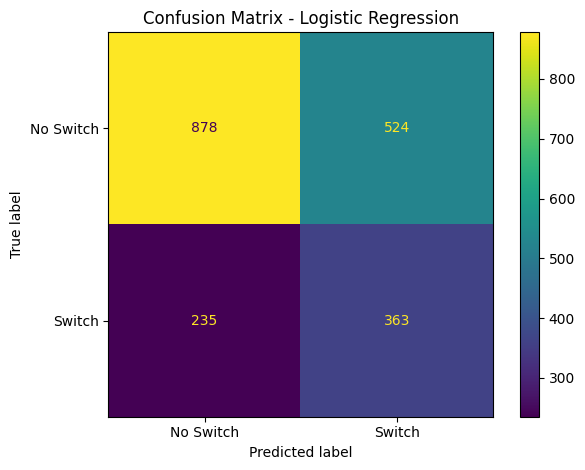

In [27]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Switch", "Switch"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.show()


### 12.3 Additional evaluation

Accuracy alone is not a fair yardstick here, because always predicting "No Switch" already scores about 70%. The cells below add a baseline, ROC-AUC, cross-validation, model coefficients, a threshold check, and two robustness checks.

,Value
ROC-AUC,0.6682
Average precision (PR-AUC),0.4475
Accuracy of 'always No' baseline,0.7010
Share of true switchers in test set,0.2990
Share of test set flagged as switchers,0.4435
Precision lift over random flagging,1.3687


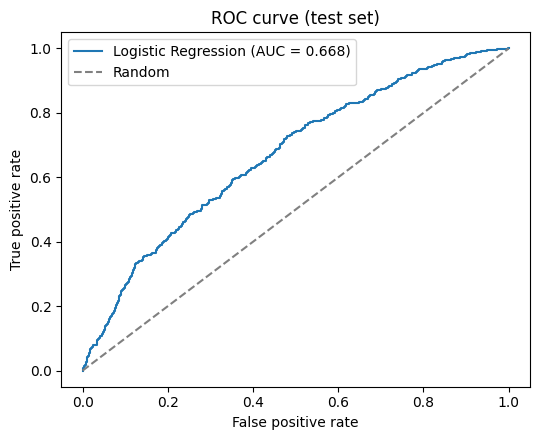

In [28]:
from sklearn.metrics import roc_auc_score, roc_curve, average_precision_score
from sklearn.dummy import DummyClassifier

proba = model.predict_proba(X_test)[:, 1]
prevalence = y_test.mean()

dummy = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
flagged_share = (y_pred == 1).mean()

summary = pd.DataFrame({
    "Value": [
        roc_auc_score(y_test, proba),
        average_precision_score(y_test, proba),
        accuracy_score(y_test, dummy.predict(X_test)),
        prevalence,
        flagged_share,
        precision / prevalence,
    ]
}, index=["ROC-AUC", "Average precision (PR-AUC)", "Accuracy of 'always No' baseline",
          "Share of true switchers in test set", "Share of test set flagged as switchers",
          "Precision lift over random flagging"]).round(4)
display(summary)

fpr, tpr, _ = roc_curve(y_test, proba)
plt.figure(figsize=(5.5, 4.5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc_score(y_test, proba):.3f})")
plt.plot([0, 1], [0, 1], "--", color="grey", label="Random")
plt.xlabel("False positive rate"); plt.ylabel("True positive rate")
plt.title("ROC curve (test set)"); plt.legend(); plt.tight_layout(); plt.show()

In [29]:
# 5-fold stratified cross-validation on all modelling records
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_validate(model, X, y, cv=cv,
                        scoring=["roc_auc", "precision", "recall", "f1", "accuracy"])
cv_table = pd.DataFrame({k.replace("test_", ""): [v.mean(), v.std()]
                         for k, v in scores.items() if k.startswith("test_")},
                        index=["mean", "std"]).T.round(4)
cv_table

,mean,std
roc_auc,0.6737,0.0094
precision,0.4194,0.0111
recall,0.6242,0.0211
f1,0.5016,0.0124
accuracy,0.6294,0.0111


In [30]:
# Which variables push the predicted switching risk up or down?
feature_names = model.named_steps["preprocessor"].get_feature_names_out()
coefs = pd.Series(model.named_steps["classifier"].coef_[0], index=feature_names)
coef_table = pd.DataFrame({"coefficient": coefs, "odds_ratio": np.exp(coefs)}).round(3)

print("Strongest factors RAISING switching risk:")
display(coef_table.sort_values("coefficient", ascending=False).head(10))
print("Strongest factors LOWERING switching risk:")
display(coef_table.sort_values("coefficient").head(10))

Strongest factors RAISING switching risk:


,coefficient,odds_ratio
categorical__Switched_Before_Yes,0.411,1.508
categorical__Competitor_Awareness_Yes,0.389,1.476
numeric__Subscriptions_Numeric,0.238,1.268
categorical__Preferred_Genre_Anime,0.085,1.089
numeric__Overall_Fatigue_Score,0.072,1.075
categorical__Usual_Viewing_Time_Evening,0.053,1.054
numeric__Content_Fatigue_Score,0.049,1.050
numeric__Cost_Fatigue_Score,0.049,1.050
categorical__Gender_Male,0.034,1.034
categorical__Preferred_Genre_Thriller,0.025,1.026


Strongest factors LOWERING switching risk:


,coefficient,odds_ratio
categorical__Switched_Before_No,-0.426,0.653
categorical__Competitor_Awareness_No,-0.405,0.667
numeric__Hours_Watched_Numeric,-0.082,0.922
categorical__Preferred_Genre_Horror,-0.076,0.926
categorical__Usual_Viewing_Time_Night,-0.068,0.934
categorical__Gender_Female,-0.049,0.952
categorical__Preferred_Genre_Comedy,-0.045,0.956
numeric__Pricing_Satisfaction,-0.045,0.956
numeric__Content_Variety,-0.040,0.961
numeric__Age_Numeric,-0.034,0.966


In [31]:
# Threshold check: the default 0.5 cut-off is not the only option
rows = []
for t in [0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    pred_t = (proba >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, pred_t, zero_division=0),
                 "recall": recall_score(y_test, pred_t, zero_division=0),
                 "f1": f1_score(y_test, pred_t, zero_division=0),
                 "share_flagged": pred_t.mean()})
pd.DataFrame(rows).round(3)

,threshold,precision,recall,f1,share_flagged
0,0.35,0.341,0.906,0.496,0.794
1,0.40,0.358,0.829,0.500,0.693
2,0.45,0.389,0.731,0.508,0.562
3,0.50,0.409,0.607,0.489,0.444
4,0.55,0.438,0.492,0.463,0.336
5,0.60,0.476,0.396,0.432,0.249


In [32]:
# Robustness check A: drop the derived fatigue scores (they are built from the ratings already in the model)
features_B = [f for f in features if "Fatigue_Score" not in f]
num_B = [c for c in features_B if pd.api.types.is_numeric_dtype(X[c])]
cat_B = [c for c in features_B if c not in num_B]

model_B = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("numeric", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), num_B),
        ("categorical", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),
                                  ("encoder", OneHotEncoder(handle_unknown="ignore"))]), cat_B)])),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=42)),
])
model_B.fit(X_train[features_B], y_train)
pred_B = model_B.predict(X_test[features_B])
proba_B = model_B.predict_proba(X_test[features_B])[:, 1]

pd.DataFrame({
    "Full model (25 features)": [accuracy, precision, recall, f1, roc_auc_score(y_test, proba)],
    "Without fatigue scores (21 features)": [accuracy_score(y_test, pred_B),
                                             precision_score(y_test, pred_B),
                                             recall_score(y_test, pred_B),
                                             f1_score(y_test, pred_B),
                                             roc_auc_score(y_test, proba_B)],
}, index=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]).round(4)

,Full model (25 features),Without fatigue scores (21 features)
Accuracy,0.6205,0.6205
Precision,0.4092,0.4092
Recall,0.6070,0.6070
F1,0.4889,0.4889
ROC-AUC,0.6682,0.6682


In [33]:
# Robustness check B: train on the synthetic rows only, then look at the real survey rows.
# There are only 13 real rows (one may lack a label), so this is a sanity check, not evidence of accuracy.
is_real = model_df["Data_Source"] == "Real"
X_syn, y_syn = X[~is_real], y[~is_real]
X_real, y_real = X[is_real], y[is_real]

from sklearn.base import clone
m_check = clone(model)                   # same pipeline, refitted on synthetic rows only
m_check.fit(X_syn, y_syn)
pred_real = m_check.predict(X_real)

print("Real rows evaluated:", len(y_real))
print("Real switchers among them:", int(y_real.sum()))
print("Accuracy on real rows:", round(accuracy_score(y_real, pred_real), 3))
display(pd.DataFrame(confusion_matrix(y_real, pred_real, labels=[0, 1]),
                     index=["Actual No", "Actual Yes"], columns=["Pred No", "Pred Yes"]))

Real rows evaluated: 12
Real switchers among them: 1
Accuracy on real rows: 0.667


,Pred No,Pred Yes
Actual No,7,4
Actual Yes,0,1


## 13. Business Insights

All figures below come from the analytical dataset (13 real + 9,987 synthetic rows), so they are directional findings, not population estimates.

1. **Switching intention is about 30% (2,988 of 9,999 labelled records).** About half of the respondents have switched a subscription before (49.9%) and about half are aware of competing services (48.9%). Switching is common, not a niche behaviour.
2. **Pricing satisfaction shows the clearest link with switching.** In the cross-tabulation, the share intending to switch falls from roughly 36% among the least price-satisfied users to roughly 25% among the most satisfied. Content satisfaction shows a similar but slightly smaller slope (about 39% to 28%), and streaming experience the flattest one (about 33% to 28%).
3. **The fatigue-score gap between switchers and non-switchers is small.** Average cost fatigue is 47.9 for intending switchers vs 45.4 for the rest; content fatigue 39.0 vs 37.6; experience fatigue 43.9 vs 43.1. The direction is consistent, the size is modest.
4. **Cost is the most common dominant fatigue type (44.25%),** followed by experience (34.51%) and content (21.24%). These shares describe all respondents. The scores for the three dimensions are on different ranges, so the ordering should be read with some care.
5. **The model is a screening tool, not a precise predictor.** At the default 0.5 cut-off it catches 60.7% of switchers (363 of 598) but only 40.9% of the people it flags really are switchers. Its accuracy (62.05%) is lower than the roughly 70% obtained by always predicting "No Switch", which is expected when class weights are used to favour recall.
6. **Data caveat.** The satisfaction items are almost uncorrelated with each other in this dataset, which is unusual for real survey data and points to how the synthetic rows were generated.

## 14. Business Recommendations

### Cost-driven fatigue
Develop targeted pricing strategies such as flexible plans, family plans, or personalized offers for price-sensitive users.

### Content-driven fatigue
Improve content personalization, content variety, and acquisition of content aligned with user preferences.

### Experience-driven fatigue
Improve streaming quality, reduce buffering, improve recommendation quality, and optimize the application experience.

### Switching-risk users
Use the classification model to identify users with higher predicted switching risk and provide targeted retention interventions.


## 15. Conclusion

This notebook takes an OTT subscription-fatigue problem from questionnaire design through cleaning, exploratory analysis, fatigue diagnosis and a class-balanced Logistic Regression model for six-month switching intention.

- **Model:** accuracy 62.05%, precision 40.92%, recall 60.70%, F1 48.89% on a 2,000-record test set. It is best used to shortlist users for low-cost retention actions.
- **Drivers:** lower pricing, content and streaming satisfaction go with a higher switching rate, with pricing showing the steepest gradient.
- **Segments:** cost, experience and content are the three fatigue types, and each points to a different retention action (Section 14).
- **Main limitation:** only 13 of the 10,000 records are real survey responses. The next step is to collect more genuine responses, re-run this notebook on them, and compare the results with those reported here.